# Cookie Cats A/B Test Analysis

## Business Question
Did moving the gate from level 30 to level 40 hurt 7-day player retention?

## Background
Cookie Cats is a mobile puzzle game. Gates force players to wait before 
continuing. The company tested whether placing the gate at level 30 vs 
level 40 affects how many players return after 7 days.

## Hypothesis
Gate 30 will retain more players because hitting a forced stop earlier 
keeps the game feeling challenging without frustrating players who are 
still early in their engagement.

## How I'll Know If I'm Right
If gate_30 shows statistically significantly higher 7-day retention 
with p < 0.05, my hypothesis is confirmed.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv('cookie_cats.csv')
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [2]:
#how many people in each version(gate)
df['version'].value_counts()
#almost equal distribution of users in both versions


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [3]:
#in each version how many did not play any game rounds
df[(df['sum_gamerounds']==0)]['version'].value_counts()

version
gate_40    2057
gate_30    1937
Name: count, dtype: int64

In [4]:
#in each version how many people retained after 7 days
df[df['retention_7']==True]['version'].value_counts()

version
gate_30    8502
gate_40    8279
Name: count, dtype: int64

In [5]:
#in each version how many people retained after 1 day
df[df['retention_1']==True]['version'].value_counts()

version
gate_40    20119
gate_30    20034
Name: count, dtype: int64

## Filtering Strategy — Modified Intention to Treat (mITT)

A player who never played a single round never encountered either gate.
Including them would dilute our results since the gate never had any 
opportunity to affect their behavior.

We remove players with sum_gamerounds = 0, keeping only those the 
experiment could actually influence. This is called mITT.

In [6]:
#remove users who didnt play a single game round
df_0=df[df['sum_gamerounds']>0]

In [7]:
df_0['version'].value_counts()

version
gate_40    43432
gate_30    42763
Name: count, dtype: int64

In [8]:
df_0[df_0['retention_7']==True]['version'].value_counts()

version
gate_30    8486
gate_40    8266
Name: count, dtype: int64

### Filtering level 30 users: keeping only those who reached level 30 as only those will show the effect done by reaching the level , adding people who didnt reached the wall would show retention which wasnt affected by the level 
### Similarly for level 40 filtering it as only those who reached level 40

In [9]:
df2=df_0[((df_0['sum_gamerounds']>29) & (df_0['version']=='gate_30'))|((df_0['sum_gamerounds']>39) & (df_0['version']=='gate_40'))]


In [10]:
df2

,userid,version,sum_gamerounds,retention_1,retention_7
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
8,1574,gate_40,108,True,True
...,...,...,...,...,...
90171,9997757,gate_30,84,True,False
90175,9998125,gate_30,30,False,False
90177,9998376,gate_40,53,False,False
90184,9999441,gate_40,97,True,False


In [11]:
df2['version'].value_counts()

version
gate_30    16656
gate_40    13827
Name: count, dtype: int64

In [12]:
df2[df2['retention_7']==True]['version'].value_counts()
#it still shows that gate 30 has more retention

version
gate_30    7308
gate_40    6707
Name: count, dtype: int64

In [13]:
#how much % users we lost after filtering CHURN RATE
#gate_30

round((43432-16656)/43432*100)

62

In [14]:
#how much % users we lost after filtering CHURN RATE
#gate_40

round((42763-13827)/42763*100)

68

In [15]:
#how much % users we lost after filtering whose retention is True after 7 days # churn rate
#gate_30

round((8486-7308)/8486*100)

14

In [16]:
#how much % users we lost after filtering whose retention is True after 7 days CHURN RATE
#gate_40
round(((8266-6707)/8266)*100)

19

### 19% reduction in wall 40 but 14% in level 30 means people are reaching out more after 7 days at wall 30 rather than level 40 , because a lot of people are not playing till level 40 as we had 68% loss in people who reach level 40 while 62% loss in users who reach level 30

In [17]:
#retention rate level 30
round((7308/16656)*100)

44

In [18]:
#retention rate level 40
round((6707/13827)*100)

49

### as the users r less in gate 40 it only has survivors so their retention is high , so we go back to not filtering the data by only keeping those who reach level 30 nd 40 nd add those peoplw who didnt reach the wall in both the walls so the analysis is equal 

In [19]:
df_0

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [20]:
gate30 = df_0[df_0['version'] == 'gate_30']
gate40 = df_0[df_0['version'] == 'gate_40']

# Step 3 - calculate retention rates
gate30_retention = gate30['retention_7'].mean() * 100
gate40_retention = gate40['retention_7'].mean() * 100

print(round(gate30_retention, 2))
print(round(gate40_retention, 2))

19.84
19.03


In [21]:
#retention rate level 40
round((df_0[df_0['retention_7']==True]['version'].value_counts()['gate_40']/df_0['version'].value_counts()['gate_40'])*100)

19

# 1. Z test

In [22]:
#two proportion z test
from statsmodels.stats.proportion import proportions_ztest

n30 = len(gate30)
n40 = len(gate40)
r30 = gate30['retention_7'].sum()
r40 = gate40['retention_7'].sum()

stat, pvalue = proportions_ztest([r30, r40], [n30, n40])
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")



Z-statistic: 3.0130
P-value: 0.0026


Interpretation
Z = 0

Observed exactly what H₀ predicts.

No difference
Z = 1

Difference is 1 standard error away.

Not very unusual
Z = 3

Difference is 3 standard errors away.

Very unusual if H₀ were true
Z = 5

Difference is 5 standard errors away.

Extremely unlikely under H₀

 p value s 0.0026 means that give h0 is true mean no diff in retention of 2 groups , there is 0.26% chance that we would see this muc diff in both group by random sampling , 0.26% is very small means no way that this diff in random.

In [23]:
import statsmodels.stats.proportion as smp

ci = smp.confint_proportions_2indep(
    r30, n30, r40, n40, 
    method='wald'
)

print(f"95% CI for difference: ({ci[0]*100:.3f}%, {ci[1]*100:.3f}%)")

95% CI for difference: (0.284%, 1.341%)


1. Does the interval contain zero?

    No. The entire interval is above zero — from 0.284% to 1.341%.
This is critical. If the interval crossed zero — say (-0.2%, 1.3%) — you couldn't confidently say gate_30 is better. Zero would mean "no difference is plausible."
Since zero is not in your interval, you're confident gate_30 is genuinely better.

2. Worst case scenario?

    0.284 percentage points. Even in the least favorable interpretation of your data, gate_30 still retains more players.

3. Best case scenario?

    1.341 percentage points. Gate_30 could be performing even better than your sample suggests.

## Business impact
### Assumptions:
- 50,000 daily new installs
- ₹5 revenue per retained player per day
- Retention difference is constant over time
- These are illustrative assumptions for business framing
- Real analysis would use actual DAU(daily active users) and LTV(lifetime value) figures

In [24]:
#Worst case
#0.284% diff in gate 30 nd 40
#for 1 day:
rw30=0.00284*50000
revenuew30=rw30*5
print('retained user in worst case if we keep gate 30 instead of 40:',rw30)
print('revenue increase in 1 day:',revenuew30)
print('annual revenue:',revenuew30*365)

retained user in worst case if we keep gate 30 instead of 40: 142.0
revenue increase in 1 day: 710.0
annual revenue: 259150.0


In [25]:
#most likely case
#0.81% diff in gate 30 nd 40
#for 1 day:
rm30=0.0081*50000
revenuem30=rm30*5
print('retained user in worst case if we keep gate 30 instead of 40:',rm30)
print('revenue increase in 1 day:',revenuem30)
print('annual revenue:',revenuem30*365)

retained user in worst case if we keep gate 30 instead of 40: 405.0
revenue increase in 1 day: 2025.0
annual revenue: 739125.0


In [26]:
#best case
#1.341% diff in gate 30 nd 40
#for 1 day:
rb30=0.01341*50000
revenueb30=rb30*5
print('retained user in worst case if we keep gate 30 instead of 40:',rb30)
print('revenue increase in 1 day:',revenueb30)
print('annual revenue:',revenueb30*365)

retained user in worst case if we keep gate 30 instead of 40: 670.5
revenue increase in 1 day: 3352.5
annual revenue: 1223662.5


## Bayesian Analysis

The Z-test told us the difference is statistically significant. 
But it can't tell us the probability that gate_30 is genuinely better.

Bayesian analysis does exactly that. We model retention rate as a 
Beta distribution where:
- Alpha = number of players retained
- Beta = number of players not retained

The distribution shows which retention rate values are most plausible 
given our data. More data = narrower distribution = more certainty.

We then simulate 100,000 draws from each distribution and measure 
how often gate_30 beats gate_40.

In [27]:
alpha_prior = 1
beta_prior = 1
alpha_30 = alpha_prior + r30
beta_30 = beta_prior + (n30 - r30)

alpha_40 = alpha_prior + r40
beta_40 = beta_prior + (n40 - r40)

from scipy import stats
import numpy as np

samples_30 = stats.beta(alpha_30, beta_30).rvs(100000)
samples_40 = stats.beta(alpha_40, beta_40).rvs(100000)

prob = (samples_30 > samples_40).mean()
prob2 = (samples_30 < samples_40).mean()
print(f"Probability gate_30 is better: {prob*100:.2f}%")
print(f"Probability gate_40 is better: {prob2*100:.2f}%")

Probability gate_30 is better: 99.87%
Probability gate_40 is better: 0.13%


In [28]:
#What 99.86% actually means
# You drew 100,000 random retention rates from each distribution and asked: in how many of those draws was gate_30 higher?
# Answer: 99,860 out of 100,000 times.
# So the statement is: given everything we observed, there is a 99.86% probability that gate_30's true retention rate is higher than gate_40's.


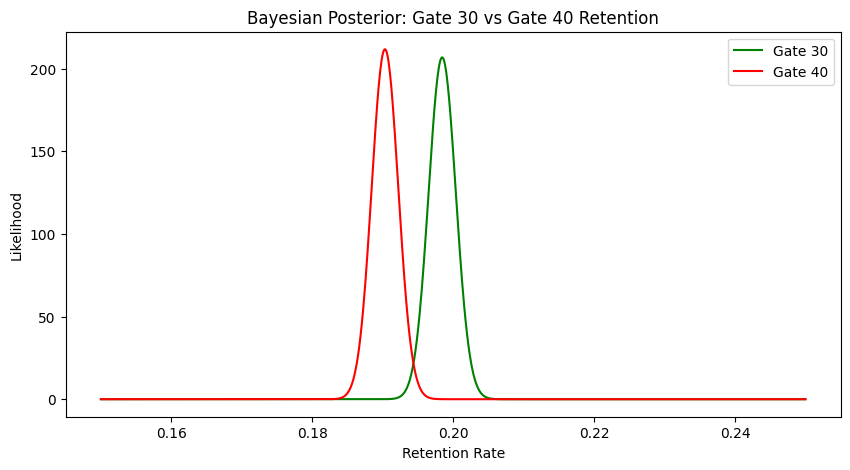

In [29]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.15, 0.25, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x, stats.beta(alpha_30, beta_30).pdf(x), label='Gate 30', color='green')
plt.plot(x, stats.beta(alpha_40, beta_40).pdf(x), label='Gate 40', color='red')

plt.xlabel('Retention Rate')
plt.ylabel('Likelihood')
plt.title('Bayesian Posterior: Gate 30 vs Gate 40 Retention')
plt.legend()
plt.show()

In [30]:
# Each curve answers: "given our data, what retention rate values are plausible?"

# Red peak is around 0.19 — gate_40's most likely true retention rate
# Green peak is around 0.20 — gate_30's most likely true retention rate
# The curves barely overlap — meaning there's almost no scenario where gate_40's true rate exceeds gate_30's

# Visualizations

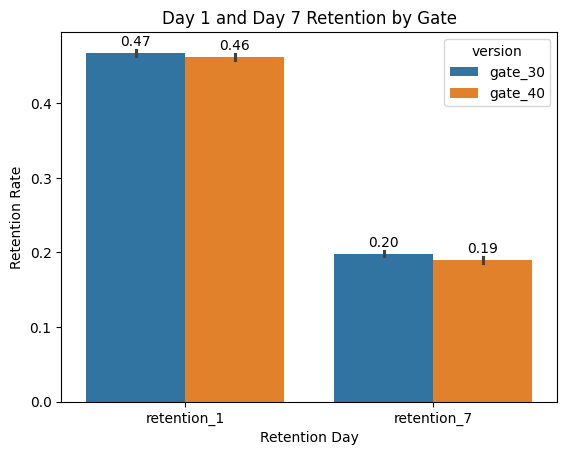

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df_0.melt(
    id_vars='version',
    value_vars=['retention_1', 'retention_7'],
    var_name='Retention Day',
    value_name='Retained'
)

sns.barplot(
    data=plot_df,
    x='Retention Day',
    y='Retained',
    hue='version'
)

plt.ylabel('Retention Rate')
plt.title('Day 1 and Day 7 Retention by Gate')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)
plt.show()

The gap between gate_30 and gate_40 is small on day 1 but more pronounced by day 7 — suggesting the gate effect compounds over time, not immediately.

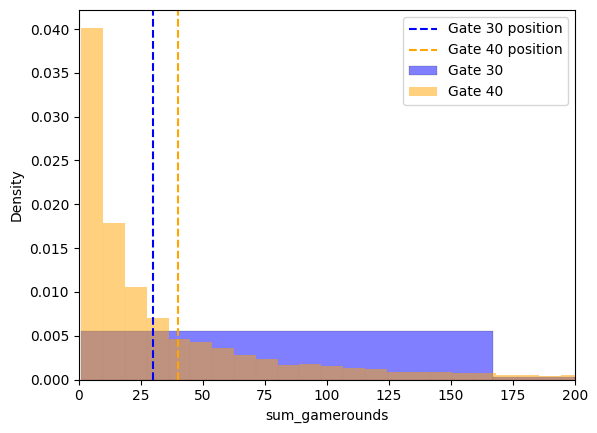

In [52]:
sns.histplot(gate30['sum_gamerounds'], bins=300,label='Gate 30', color='blue', alpha=0.5, stat='density')
sns.histplot(gate40['sum_gamerounds'], bins=300,label='Gate 40', color='orange', alpha=0.5, stat='density')

plt.xlim(0, 200)
plt.axvline(x=30, color='blue', linestyle='--', label='Gate 30 position')
plt.axvline(x=40, color='orange', linestyle='--', label='Gate 40 position')
plt.legend()

-Gate 40 (orange) — drops sharply right at x=40 (the orange dashed line). Density falls close to zero after that. Players hit level 40, can't pass, and quit. The gate is clearly causing churn.

-Gate 30 (blue) — does NOT drop at x=30. Instead it stays relatively flat all the way to 175 rounds. Players are passing gate 30 and continuing to play.

-This is actually your most important visual insight.

-It tells you: gate_30 is easy enough that players pass it and keep playing. Gate_40 is hard enough that it acts as a wall — most players quit right there.

## Conclusion

We tested whether moving Cookie Cats' gate from level 30 to level 40 
affects 7-day player retention across 86,000 players.

Gate 30 retained 19.84% of players at day 7 compared to 19.03% for 
gate 40 — a difference of 0.81 percentage points. Both frequentist 
analysis (p=0.0026, 95% CI: 0.284% to 1.341%) and Bayesian analysis 
(99.86% probability gate 30 is genuinely better) confirm this is not 
due to random chance.

The density plot provides visual confirmation — gate 40 causes a sharp 
player drop-off at round 40 while gate 30 players continue playing well 
beyond round 30.

Based on illustrative assumptions of 50,000 daily installs and ₹5 
revenue per retained player, switching to gate 40 would cost between 
₹2,59,150 and ₹12,23,662 annually.

Recommendation: Keep the gate at level 30.

Limitations: Revenue figures are illustrative. Real business impact 
requires actual DAU and LTV data. Novelty effects and long-term 
retention trends were not analyzed.